# Generating realistic metaorders from trade data

<div style="font-size:120%">

We provide below the code used in [Generating realistic metaorders from synthetic data](https://arxiv.org/pdf/2503.18199).  
As highlighted in the article, generating synthetic metaorders from a synthetic price does **not** yield the observed square-root law (SQL). However, replacing the synthetic price with **real trade data** - while keeping the same algorithm — allows one to recover the results presented in the paper. 

When working with real trade data, we recommend the following preprocessing steps:

- Rescale trade sizes by the corresponding daily traded volume  
- Rescale prices by taking the logarithm and dividing by the daily volatility

</div>


In [38]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.stats import powerlaw

# Formatting the data

We expect the trade data to include at least the following columns:
- `timestamp` (with both date and time)
- `sign` or `side` (indicating the trade direction)
- `quantity` (trade size)
- `midprice` (current mid price at the beginning of the trade)


The trade sign can be determined by labelling a trade as a buy (or sell) if its price is higher (or lower) than the midprice. The SQL also holds when using trade prices directly instead of the midprice.



In [39]:
### Generate a trade data for example
timestamp = pd.date_range(start='2024-01-01', end='2024-01-08',freq='1s')
nb_trades = len(timestamp)
sign = 2*np.random.randint(0,2,nb_trades)-1
qty = np.random.randint(10,100,nb_trades)   
price = np.cumsum(sign*qty**0.5)
price = price - np.min(price) + 1
trades = pd.DataFrame({'timestamp':timestamp,'sign':sign,'quantity':qty,'midprice':price})

trades.head()


,timestamp,sign,quantity,midprice
0,2024-01-01 00:00:00,1,27,5113.370925
1,2024-01-01 00:00:01,-1,84,5104.205774
2,2024-01-01 00:00:02,-1,73,5095.661770
3,2024-01-01 00:00:03,-1,73,5087.117766
4,2024-01-01 00:00:04,-1,46,5080.335436


To proceed, we apply a normalization using both the daily volatility and daily traded volume.

In [40]:
trades['day'] = trades['timestamp'].dt.date

# Calculate daily volatility and volume
daily_stats = trades.groupby('day').agg(
    DailySigma=('midprice', lambda x: (x.max() - x.min()) / x.iloc[0]),  # (max - min) / open
    DailyVolume=('quantity', 'sum')  # Sum of quantity for each day
).reset_index()


trades = trades.merge(daily_stats, on='day', how='left')
trades['BeginMid'] = np.log(trades['midprice']) / trades['DailySigma']
trades['RescaledVolume'] = trades['quantity'] / trades['DailyVolume']

# Generating synthetic metaorders

In [41]:
def generate_meta(df,nb_traders,kind,exponent):
    '''
    Generate metaorders from trades
    Inputs :
    df : DataFrame with trades
    nb_traders : number of traders, (int)
    kind :  type of distribution for trading frequencies ('homogeneous' or 'power'), (str)
    exponent : exponent of the distribution (if kind = 'power'), (int)

    Outputs :
    metaorders : DataFrame with synthetic metaorders
    '''

    ### Attribute to each trade a trader thanks to a mapping function
    df['trader'] = mapping_function(df,nb_traders,kind,exponent) 

    ### Aggregate metaorders, defined as a sequence of trades with the same sign from the same trader 
    sorted_trades  = df.sort_values(['trader','timestamp']).reset_index(drop=True)
    sorted_trades['metaid'] = np.where((sorted_trades['trader']!=sorted_trades['trader'].shift())|( sorted_trades.sign.shift()!= sorted_trades.sign)|(sorted_trades.day!= sorted_trades.day.shift()),1,0).cumsum() # In our definition, a metaorder should be executed within a single day 


    ### Compute the metaorder features
    sorted_trades['EndMid'] = sorted_trades['BeginMid'].shift(-1) # End Mid price of the metaorder 
    sorted_trades['EndTime'] = sorted_trades['timestamp'].shift(-1) # End Time of the metaorder  
    sorted_trades = sorted_trades.dropna()
    sorted_trades = sorted_trades.groupby('metaid').agg({'sign':'first','BeginMid':'first','EndMid':'last',
                                 'trader':'count','timestamp':'first','EndTime':'last','RescaledVolume':'sum'}).reset_index(drop=True)
    sorted_trades = sorted_trades.rename(columns={'trader': 'NbChild','RescaledVolume':'MetaVolume','timestamp':'BeginTime'})
    sorted_trades['MetaDuration'] = (sorted_trades.EndTime - sorted_trades.BeginTime).dt.total_seconds()
    sorted_trades['MetaImpact'] = (sorted_trades.EndMid-sorted_trades.BeginMid)*sorted_trades.sign # Multiply by sign to get the impact in the right direction
    

    # Return metaorders with more than one child (or more, if longer metaorders are desired)
    metaorders = sorted_trades[sorted_trades.NbChild > 1].reset_index(drop=True)
    print('Number of metaorders ',len(sorted_trades))
    return metaorders


def mapping_function(df,nb_traders,kind,alpha) :
    '''
    Given a trading frequency distribution, generate a list of traders for each trade
    Inputs :
    df : DataFrame with trades
    nb_traders : number of traders  
    kind : type of distribution for the trader's frequency
    alpha : exponent of the distribution (if kind = 'power')

    Outputs :
    traders : list of traders for each trade
    '''
    ### Choose a trading frequency distribution
    if kind == 'power':
        samples = powerlaw.rvs(int(alpha), size=int(nb_traders))
    if kind =='uniform':
        samples = np.ones(nb_traders)
    frequencies = samples / samples.sum()
    cum_freq = np.cumsum(frequencies)
    traders = []

    ### Assign traders to trades
    for _ in range (len(df)):
        u = random.random()
        trader_index = np.searchsorted(cum_freq,u)
        traders.append(f"Trader {trader_index+1}")
    return traders


In [42]:
#Example usage. The values of these parameters should be fine-tuned based on the asset being considered, to obtain the correct SQL.
nb_traders = 10
kind = 'power'
exponent = 2.5


synthetic_meta = generate_meta(trades,nb_traders,kind,exponent)
synthetic_meta.head()

Number of metaorders  301818


,sign,BeginMid,EndMid,NbChild,BeginTime,EndTime,MetaVolume,MetaDuration,MetaImpact
0,-1,17.665653,17.644117,2,2024-01-01 00:00:08,2024-01-01 00:00:34,0.000019,26.0,0.021536
1,-1,17.645950,17.640341,2,2024-01-01 00:00:49,2024-01-01 00:00:52,0.000035,3.0,0.005609
2,1,17.670281,17.672106,3,2024-01-01 00:01:28,2024-01-01 00:01:44,0.000035,16.0,0.001825
3,1,17.671109,17.672819,3,2024-01-01 00:01:55,2024-01-01 00:02:14,0.000032,19.0,0.001711
4,1,17.677228,17.666133,4,2024-01-01 00:02:37,2024-01-01 00:03:21,0.000046,44.0,-0.011095


In [43]:
synthetic_meta['day'] = synthetic_meta['BeginTime'].dt.date

daily_stats = synthetic_meta.groupby('day').agg(
    DailyVolume=('MetaVolume', 'sum')  # Sum of quantity for each day
).reset_index()


synthetic_meta = synthetic_meta.merge(daily_stats, on='day', how='left')
synthetic_meta['ParticipationRatio'] = synthetic_meta['MetaVolume'] / synthetic_meta['DailyVolume']
synthetic_meta.head()

,sign,BeginMid,EndMid,NbChild,BeginTime,EndTime,MetaVolume,MetaDuration,MetaImpact,day,DailyVolume,ParticipationRatio
0,-1,17.665653,17.644117,2,2024-01-01 00:00:08,2024-01-01 00:00:34,0.000019,26.0,0.021536,2024-01-01,0.749778,0.000026
1,-1,17.645950,17.640341,2,2024-01-01 00:00:49,2024-01-01 00:00:52,0.000035,3.0,0.005609,2024-01-01,0.749778,0.000047
2,1,17.670281,17.672106,3,2024-01-01 00:01:28,2024-01-01 00:01:44,0.000035,16.0,0.001825,2024-01-01,0.749778,0.000047
3,1,17.671109,17.672819,3,2024-01-01 00:01:55,2024-01-01 00:02:14,0.000032,19.0,0.001711,2024-01-01,0.749778,0.000043
4,1,17.677228,17.666133,4,2024-01-01 00:02:37,2024-01-01 00:03:21,0.000046,44.0,-0.011095,2024-01-01,0.749778,0.000061


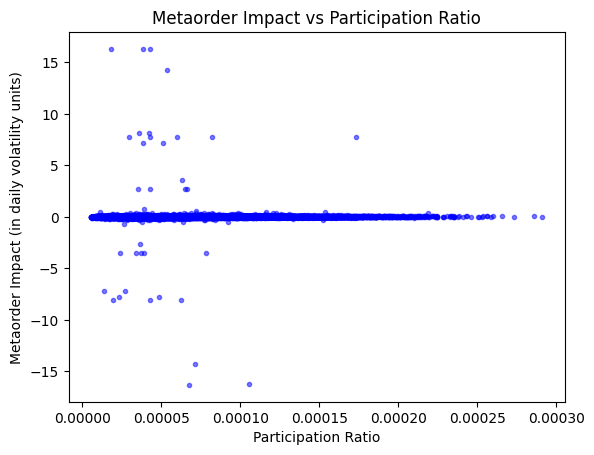

In [44]:
plt.plot(synthetic_meta.ParticipationRatio,synthetic_meta.MetaImpact,'.', color='blue', alpha=0.5)
plt.xlabel('Participation Ratio')
plt.ylabel('Metaorder Impact (in daily volatility units)')
plt.title('Metaorder Impact vs Participation Ratio')
plt.show()


In [45]:
df = pd.read_parquet('../data/raw/SPY.P_smid_full.parquet')
df = df.rename(columns={'index':'timestamp', 'mid' :'midprice', 'trade-volume':'quantity', 's' : 'sign'})
df.head()

,timestamp,midprice,sign,quantity
0,2008-08-15 13:30:00.616,129.935,-1.0,15611
1,2008-08-15 13:30:00.640,129.935,-1.0,2237
2,2008-08-15 13:30:00.652,129.935,1.0,3100
3,2008-08-15 13:30:00.788,129.935,-1.0,150
4,2008-08-15 13:30:00.875,129.945,-1.0,1900


In [46]:
df['day'] = df['timestamp'].dt.date

# Calculate daily volatility and volume
daily_stats = df.groupby('day').agg(
    DailySigma=('midprice', lambda x: (x.max() - x.min()) / x.iloc[0]),  # (max - min) / open
    DailyVolume=('quantity', 'sum')  # Sum of quantity for each day
).reset_index()


df = df.merge(daily_stats, on='day', how='left')
df['BeginMid'] = np.log(df['midprice']) / df['DailySigma']
df['RescaledVolume'] = df['quantity'] / df['DailyVolume']

In [47]:
nb_traders = 10
kind = 'power'
exponent = 2.5


synthetic_meta = generate_meta(df,nb_traders,kind,exponent)
synthetic_meta.head()

Number of metaorders  23132918


,sign,BeginMid,EndMid,NbChild,BeginTime,EndTime,MetaVolume,MetaDuration,MetaImpact
0,-1.0,531.426979,531.397563,3,2008-08-15 13:30:08.466,2008-08-15 13:30:25.816,0.000046,17.350,0.029416
1,-1.0,531.426979,531.431181,2,2008-08-15 13:30:56.291,2008-08-15 13:30:57.175,0.000050,0.884,-0.004202
2,1.0,531.447985,531.489986,3,2008-08-15 13:30:57.903,2008-08-15 13:31:07.937,0.000049,10.034,0.042001
3,-1.0,531.485787,531.485787,7,2008-08-15 13:31:20.689,2008-08-15 13:31:39.442,0.000286,18.753,-0.000000
4,1.0,531.519377,531.506782,2,2008-08-15 13:31:42.816,2008-08-15 13:31:43.646,0.000520,0.830,-0.012595


In [48]:
synthetic_meta['day'] = synthetic_meta['BeginTime'].dt.date

daily_stats = synthetic_meta.groupby('day').agg(
    DailyVolume=('MetaVolume', 'sum')  # Sum of quantity for each day
).reset_index()


synthetic_meta = synthetic_meta.merge(daily_stats, on='day', how='left')
synthetic_meta['ParticipationRatio'] = synthetic_meta['MetaVolume'] / synthetic_meta['DailyVolume']
synthetic_meta.head()

,sign,BeginMid,EndMid,NbChild,BeginTime,EndTime,MetaVolume,MetaDuration,MetaImpact,day,DailyVolume,ParticipationRatio
0,-1.0,531.426979,531.397563,3,2008-08-15 13:30:08.466,2008-08-15 13:30:25.816,0.000046,17.350,0.029416,2008-08-15,0.687929,0.000067
1,-1.0,531.426979,531.431181,2,2008-08-15 13:30:56.291,2008-08-15 13:30:57.175,0.000050,0.884,-0.004202,2008-08-15,0.687929,0.000072
2,1.0,531.447985,531.489986,3,2008-08-15 13:30:57.903,2008-08-15 13:31:07.937,0.000049,10.034,0.042001,2008-08-15,0.687929,0.000072
3,-1.0,531.485787,531.485787,7,2008-08-15 13:31:20.689,2008-08-15 13:31:39.442,0.000286,18.753,-0.000000,2008-08-15,0.687929,0.000416
4,1.0,531.519377,531.506782,2,2008-08-15 13:31:42.816,2008-08-15 13:31:43.646,0.000520,0.830,-0.012595,2008-08-15,0.687929,0.000756


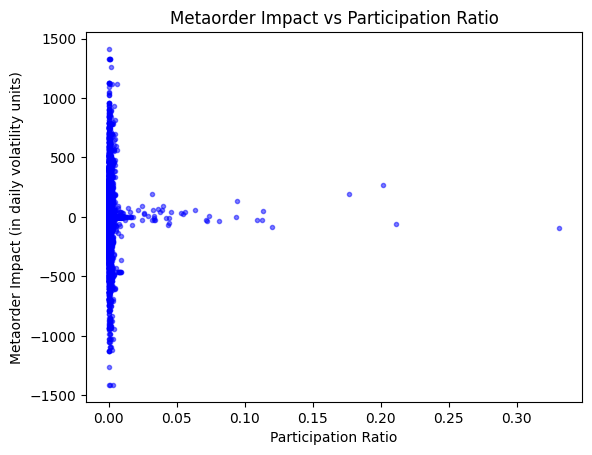

In [49]:
plt.plot(synthetic_meta.ParticipationRatio,synthetic_meta.MetaImpact,'.', color='blue', alpha=0.5)
plt.xlabel('Participation Ratio')
plt.ylabel('Metaorder Impact (in daily volatility units)')
plt.title('Metaorder Impact vs Participation Ratio')
plt.show()
